In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib import gridspec
import pandas as pd
import seaborn as sns

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 14,
    "axes.linewidth": 1.2,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    'grid.linestyle':    '--',
    'grid.linewidth':    0.4,
    'axes.linewidth':   0.8,
})

def bootstrap_ci_width(x, n_resamples=10):
    """Return upper 95% bootstrap CI distance from the mean."""
    result = stats.bootstrap(
        (x.dropna().values,),
        np.mean,
        confidence_level=0.95,
        n_resamples=n_resamples,
        random_state=1,
        method="percentile",
    )
    mean = np.mean(x)
    return result.confidence_interval.high - mean


def clean_axis(ax, xlabel="", ylabel=""):
    """Apply minimal Nature-style axis formatting."""
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(direction="out", length=4, width=1.1)

# Load data

In [2]:
df1 = pd.read_parquet("data_first_au.parquet")

In [3]:
df1["AIProb"] = df1["AIProb"]*100

C:\Users\nd\AppData\Local\Temp\ipykernel_6252\48671407.py:200: RuntimeWarning: All-NaN slice encountered
  np.nanmin(heat_gender_p.values),
C:\Users\nd\AppData\Local\Temp\ipykernel_6252\48671407.py:201: RuntimeWarning: All-NaN slice encountered
  np.nanmin(heat_entropy.values)
C:\Users\nd\AppData\Local\Temp\ipykernel_6252\48671407.py:199: RuntimeWarning: All-NaN axis encountered
  vmin = np.nanmin([
C:\Users\nd\AppData\Local\Temp\ipykernel_6252\48671407.py:205: RuntimeWarning: All-NaN slice encountered
  np.nanmax(heat_gender_p.values),
C:\Users\nd\AppData\Local\Temp\ipykernel_6252\48671407.py:206: RuntimeWarning: All-NaN slice encountered
  np.nanmax(heat_entropy.values)
C:\Users\nd\AppData\Local\Temp\ipykernel_6252\48671407.py:204: RuntimeWarning: All-NaN axis encountered
  vmax = np.nanmax([


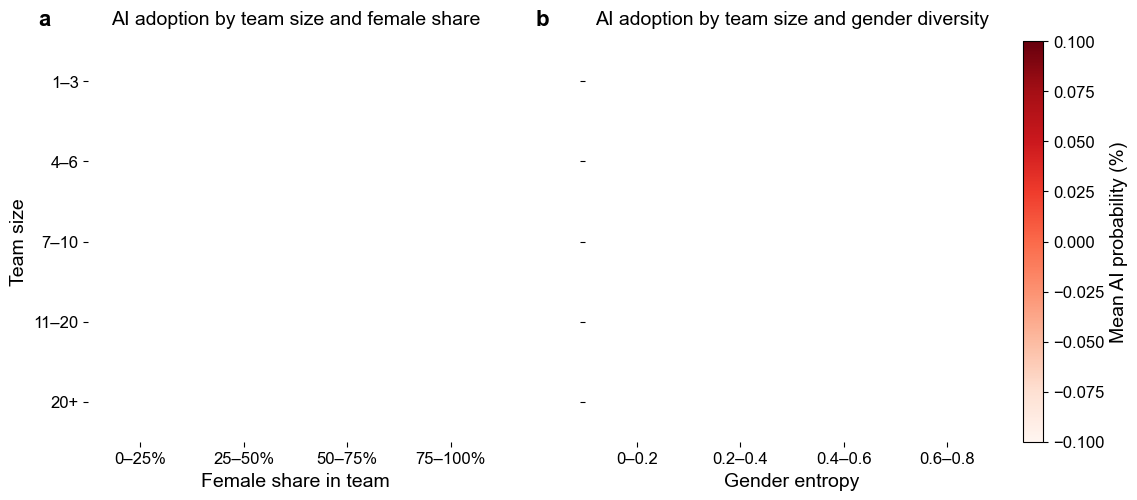

In [4]:
plot_df = df1.copy()

plot_df = plot_df.dropna(
    subset=["Gender_P", "Gender_entropy", "team_size", "AIProb"]
).copy()

plot_df = plot_df[
    (plot_df["Gender_P"] >= 0) &
    (plot_df["Gender_P"] <= 1) &
    (plot_df["Gender_entropy"] >= 0) &
    (plot_df["team_size"] >= 1)
].copy()


# --------------------
# Team size bins
# --------------------

team_bins = [0, 3, 6, 10, 20, np.inf]

team_labels = [
    "1–3",
    "4–6",
    "7–10",
    "11–20",
    "20+"
]

plot_df["team_bin"] = pd.cut(
    plot_df["team_size"],
    bins=team_bins,
    labels=team_labels,
    include_lowest=True
)


# --------------------
# Composition bins
# --------------------

gender_p_bins = [0, 0.25, 0.50, 0.75, 1.00]

gender_p_labels = [
    "0–25%",
    "25–50%",
    "50–75%",
    "75–100%"
]

plot_df["Gender_P_bin"] = pd.cut(
    plot_df["Gender_P"],
    bins=gender_p_bins,
    labels=gender_p_labels,
    include_lowest=True
)


entropy_bins = [0, 0.2, 0.4, 0.6, 0.8]

entropy_labels = [
    "0–0.2",
    "0.2–0.4",
    "0.4–0.6",
    "0.6–0.8"
]

plot_df["Gender_entropy_bin"] = pd.cut(
    plot_df["Gender_entropy"],
    bins=entropy_bins,
    labels=entropy_labels,
    include_lowest=True
)


# --------------------
# Helper functions
# --------------------

def make_heat_mats(df, x_col, x_labels):
    heat_df = (
        df
        .groupby(
            ["team_bin", x_col],
            observed=True
        )
        .agg(
            mean_AIProb=("AIProb", "mean"),
            n=("AIProb", "size")
        )
        .reset_index()
    )

    heat_mat = (
        heat_df
        .pivot(
            index="team_bin",
            columns=x_col,
            values="mean_AIProb"
        )
        .reindex(index=team_labels, columns=x_labels)
    )

    n_mat = (
        heat_df
        .pivot(
            index="team_bin",
            columns=x_col,
            values="n"
        )
        .reindex(index=team_labels, columns=x_labels)
    )

    return heat_mat, n_mat


def draw_heatmap(ax, heat_mat, n_mat, x_labels, xlabel, title, vmin, vmax):
    im = ax.imshow(
        heat_mat.values,
        aspect="auto",
        interpolation="nearest",
        cmap="Reds",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels)

    ax.set_yticks(np.arange(len(team_labels)))
    ax.set_yticklabels(team_labels)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Team size")
    ax.set_title(title, pad=12)

    ax.set_xticks(
        np.arange(-0.5, len(x_labels), 1),
        minor=True
    )

    ax.set_yticks(
        np.arange(-0.5, len(team_labels), 1),
        minor=True
    )

    ax.grid(
        which="minor",
        color="white",
        linestyle="-",
        linewidth=1
    )

    ax.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    for i in range(len(team_labels)):
        for j in range(len(x_labels)):
            val = heat_mat.iloc[i, j]

            if pd.isna(val):
                continue

            ax.text(
                j,
                i,
                f"{val:.2f}%",
                ha="center",
                va="center",
                color="black"
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

    return im


# --------------------
# Build matrices
# --------------------

heat_gender_p, n_gender_p = make_heat_mats(
    plot_df,
    x_col="Gender_P_bin",
    x_labels=gender_p_labels
)

heat_entropy, n_entropy = make_heat_mats(
    plot_df,
    x_col="Gender_entropy_bin",
    x_labels=entropy_labels
)


# Shared color scale
vmin = np.nanmin([
    np.nanmin(heat_gender_p.values),
    np.nanmin(heat_entropy.values)
])

vmax = np.nanmax([
    np.nanmax(heat_gender_p.values),
    np.nanmax(heat_entropy.values)
])


# --------------------
# Plot
# --------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 5.2),
    sharey=True
)

im1 = draw_heatmap(
    axes[0],
    heat_gender_p,
    n_gender_p,
    x_labels=gender_p_labels,
    xlabel="Female share in team",
    title="AI adoption by team size and female share",
    vmin=vmin,
    vmax=vmax
)

im2 = draw_heatmap(
    axes[1],
    heat_entropy,
    n_entropy,
    x_labels=entropy_labels,
    xlabel="Gender entropy",
    title="AI adoption by team size and gender diversity",
    vmin=vmin,
    vmax=vmax
)

axes[1].set_ylabel("")

cbar = fig.colorbar(
    im2,
    ax=axes,
    fraction=0.035,
    pad=0.025
)

cbar.set_label("Mean AI probability (%)")

for ax, label in zip(axes, ["a", "b"]):
    ax.text(
        -0.12,
        1.08,
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        va="top"
    )

plt.savefig(
    "Data/fig5_team_gender.pdf",
    bbox_inches="tight"
)

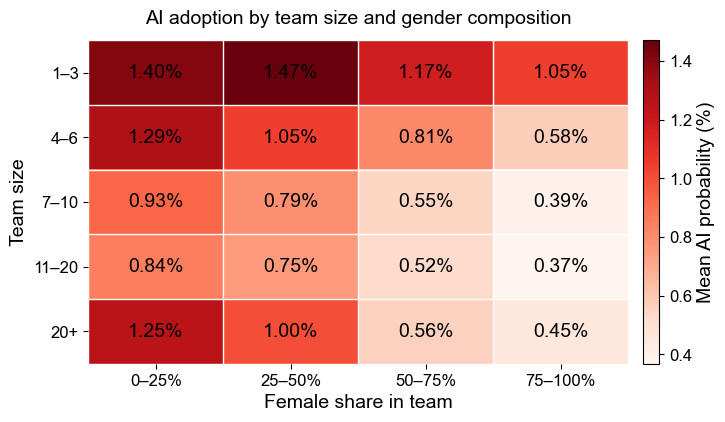

In [5]:
plot_df = df1.copy()

plot_df = plot_df.dropna(
    subset=["Gender_P", "team_size", "AIProb"]
).copy()

plot_df = plot_df[
    (plot_df["Gender_P"] >= 0) &
    (plot_df["Gender_P"] <= 1) &
    (plot_df["team_size"] >= 1)
].copy()


# --------------------
# Team size bins
# --------------------

team_bins = [0, 3, 6, 10, 20, np.inf]

team_labels = [
    "1–3",
    "4–6",
    "7–10",
    "11–20",
    "20+"
]

plot_df["team_bin"] = pd.cut(
    plot_df["team_size"],
    bins=team_bins,
    labels=team_labels,
    include_lowest=True
)


# --------------------
# Gender composition bins
# --------------------

gender_bins = [0, 0.25, 0.50, 0.75, 1.00]

gender_labels = [
    "0–25%",
    "25–50%",
    "50–75%",
    "75–100%"
]

plot_df["gender_bin"] = pd.cut(
    plot_df["Gender_P"],
    bins=gender_bins,
    labels=gender_labels,
    include_lowest=True
)


# --------------------
# Summarize
# --------------------

heat_df = (
    plot_df
    .groupby(
        ["team_bin", "gender_bin"],
        observed=True
    )
    .agg(
        mean_AIProb=("AIProb", "mean"),
        n=("AIProb", "size")
    )
    .reset_index()
)

heat_mat = (
    heat_df
    .pivot(
        index="team_bin",
        columns="gender_bin",
        values="mean_AIProb"
    )
    .reindex(index=team_labels, columns=gender_labels)
)

n_mat = (
    heat_df
    .pivot(
        index="team_bin",
        columns="gender_bin",
        values="n"
    )
    .reindex(index=team_labels, columns=gender_labels)
)


# --------------------
# Plot heatmap
# --------------------

fig, ax = plt.subplots(figsize=(7.5, 4.2))

im = ax.imshow(
    heat_mat.values,
    aspect="auto",
    interpolation="nearest",
    cmap="Reds"
)

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.025
)

cbar.set_label(
    "Mean AI probability (%)"
)



# --------------------
# Axes
# --------------------

ax.set_xticks(np.arange(len(gender_labels)))
ax.set_xticklabels(
    gender_labels
)

ax.set_yticks(np.arange(len(team_labels)))
ax.set_yticklabels(
    team_labels
)

ax.set_xlabel(
    "Female share in team"
)

ax.set_ylabel(
    "Team size"
)

ax.set_title(
    "AI adoption by team size and gender composition",
    pad=12
)


# --------------------
# Cell borders
# --------------------

ax.set_xticks(
    np.arange(-0.5, len(gender_labels), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(team_labels), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linestyle="-",
    linewidth=1
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)


# --------------------
# Annotate cells
# --------------------

threshold = np.nanmean(heat_mat.values)

for i in range(len(team_labels)):
    for j in range(len(gender_labels)):

        val = heat_mat.iloc[i, j]
        n = n_mat.iloc[i, j]

        if pd.isna(val):
            continue

        text_color = "white" if val > threshold else "black"

        ax.text(
            j,
            i,
            f"{val:.2f}"+"%",
            ha="center",
            va="center",
            color='k'
        )


# --------------------
# Clean frame
# --------------------

for spine in ax.spines.values():
    spine.set_visible(False)

plt.savefig(
    "Data/fig5_team_gender.pdf",
    bbox_inches="tight"
)